In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv(r"D:\University\Computer Program\ML_project\Supervised learning\House Prices - Advanced Regression Techniques\house-prices-advanced-regression-techniques\train.csv")
missing_ratio = train.isnull().sum().sort_values(ascending=False) / len(train)
print(missing_ratio[missing_ratio > 0]) # 看一下缺失率高的特征
# PoolQC 0.995205 MiscFeature 0.963014 Alley 0.937671 Fence 0.807534

train.drop(columns=["PoolQC","MiscFeature","Alley","Fence"], inplace=True)


PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageQual      0.055479
GarageFinish    0.055479
GarageType      0.055479
GarageYrBlt     0.055479
GarageCond      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtCond        0.025342
BsmtQual        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
dtype: float64


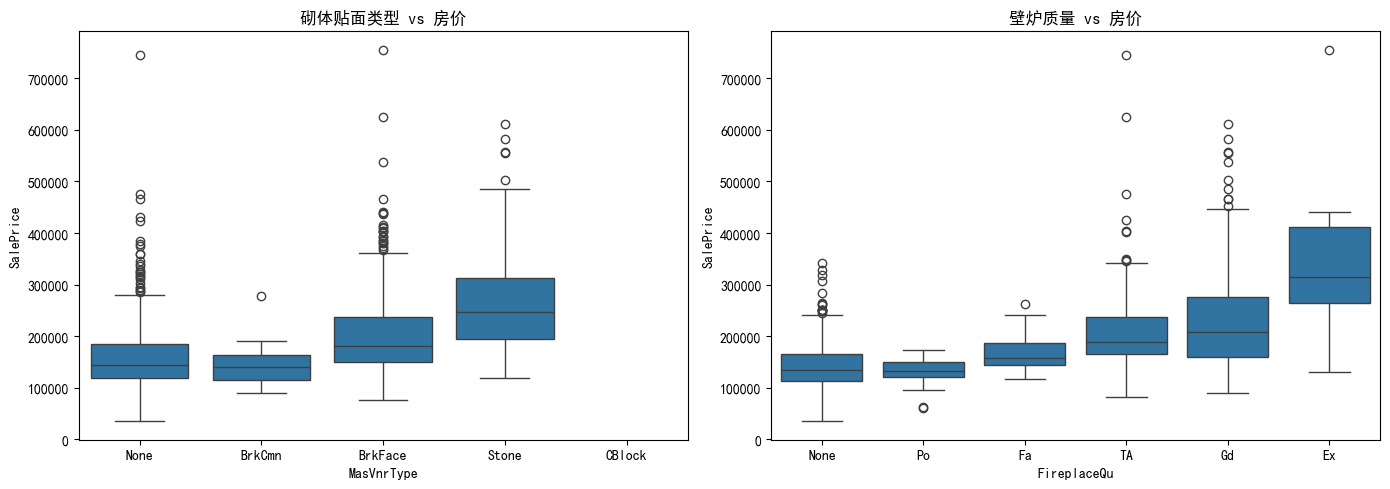

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 先把NaN变成'None'，让它作为正常类别参与分组
plt.rcParams['font.sans-serif'] = ['SimHei']   # Windows用黑体
plt.rcParams['axes.unicode_minus'] = False 
df_plot = train.copy()
df_plot['MasVnrType'] = df_plot['MasVnrType'].fillna('None')
df_plot['FireplaceQu'] = df_plot['FireplaceQu'].fillna('None')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：MasVnrType vs SalePrice
sns.boxplot(x='MasVnrType', y='SalePrice', data=df_plot, ax=axes[0],
            order=['None', 'BrkCmn', 'BrkFace', 'Stone', 'CBlock'])
axes[0].set_title('砌体贴面类型 vs 房价')
axes[0].set_xlabel('MasVnrType')

# 图2：FireplaceQu vs SalePrice
sns.boxplot(x='FireplaceQu', y='SalePrice', data=df_plot, ax=axes[1],
            order=['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'])
axes[1].set_title('壁炉质量 vs 房价')
axes[1].set_xlabel('FireplaceQu')

plt.tight_layout()
plt.show()

In [14]:
# 处理一下非数值数据
nominal_cols = [
    'MSSubClass',      # 建筑类型编码（虽是数字但是类别）
    'MSZoning',        # 土地规划分类
    'Street',          # 道路类型
    'LotShape',        # 地块形状（Reg/IR1/IR2/IR3，不规则度有顺序但弱，One-Hot也可以）
    'LandContour',     # 地块平坦度
    'LotConfig',       # 地块位置类型
    'LandSlope',       # 坡度
    'Neighborhood',    # 社区
    'Condition1',      # 邻近条件1
    'Condition2',      # 邻近条件2
    'BldgType',        # 住宅类型
    'HouseStyle',      # 建筑风格
    'RoofStyle',       # 屋顶形状
    'RoofMatl',        # 屋顶材料
    'Exterior1st',     # 第一层外墙材料
    'Exterior2nd',     # 第二层外墙材料
    'MasVnrType',      # 砌体贴面类型（已填None）
    'Foundation',      # 地基类型
    'Heating',         # 暖气类型
    'Electrical',      # 电力系统
    'GarageType',      # 车库位置
    'SaleType',        # 销售类型
    'SaleCondition',   # 销售条件
]
# 1. 把要编码的列的 NaN 全填 'None'
train[nominal_cols] = train[nominal_cols].fillna('None')

# 2. MSSubClass 是数字，先转成字符串
train['MSSubClass'] = train['MSSubClass'].astype(str)

# 3. One-Hot 编码（只跑一次）
train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)

# 4. 验证
print(f"编码后特征数: {train.shape[1]}")
print(f"剩余 object 列: {train.select_dtypes(include=['object']).columns.tolist()}")


编码后特征数: 213
剩余 object 列: ['Utilities', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'CentralAir', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17036\2336711706.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"剩余 object 列: {train.select_dtypes(include=['object']).columns.tolist()}")


In [15]:
# ========== 有序类别 ==========
ordinal_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'GarageFinish'
]

# 映射字典
quality_map      = {'None': 0, 'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4}
exposure_map     = {'None': 0, 'No': 0, 'Mn': 1, 'Av': 2, 'Gd': 3}
fin_type_map     = {'None': 0, 'Unf': 0, 'LwQ': 1, 'Rec': 2, 'BLQ': 3, 'ALQ': 4, 'GLQ': 5}
garage_finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}

for col in ordinal_cols:
    if col not in train.columns:
        continue
    train[col] = train[col].fillna('None')
    if col == 'BsmtExposure':
        train[col] = train[col].map(exposure_map)
    elif col in ['BsmtFinType1', 'BsmtFinType2']:
        train[col] = train[col].map(fin_type_map)
    elif col == 'GarageFinish':
        train[col] = train[col].map(garage_finish_map)
    else:
        train[col] = train[col].map(quality_map)

# ========== 二值类别 ==========
# CentralAir: Y/N → 1/0
if 'CentralAir' in train.columns:
    train['CentralAir'] = train['CentralAir'].map({'N': 0, 'Y': 1})

# PavedDrive: Y/P/N → 2/1/0（有序倾向，但简单映射就行）
if 'PavedDrive' in train.columns:
    train['PavedDrive'] = train['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})

# ========== 剩余杂项 ==========
# Utilities: 几乎全是 AllPub，直接删
if 'Utilities' in train.columns:
    train.drop('Utilities', axis=1, inplace=True)

# Functional: 有序（Typ>Min1>Min2>Mod>Maj1>Maj2>Sev>Sal）
func_map = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}
if 'Functional' in train.columns:
    train['Functional'] = train['Functional'].fillna('Typ')
    train['Functional'] = train['Functional'].map(func_map)

# ========== 验证 ==========
obj_cols = train.select_dtypes(include=['object']).columns.tolist()
print(f"剩余 object 列: {obj_cols}")  # 应该是空列表
print(f"缺失值: {train.isnull().sum().sum()}")  # 应该 0

剩余 object 列: []
缺失值: 348


In [16]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)


LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64


In [17]:
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)         # 0 表示无车库
train['MasVnrArea']  = train['MasVnrArea'].fillna(0)          # 0 表示无贴面

print("缺失值:", train.isnull().sum().sum())  # 应该 0

缺失值: 0


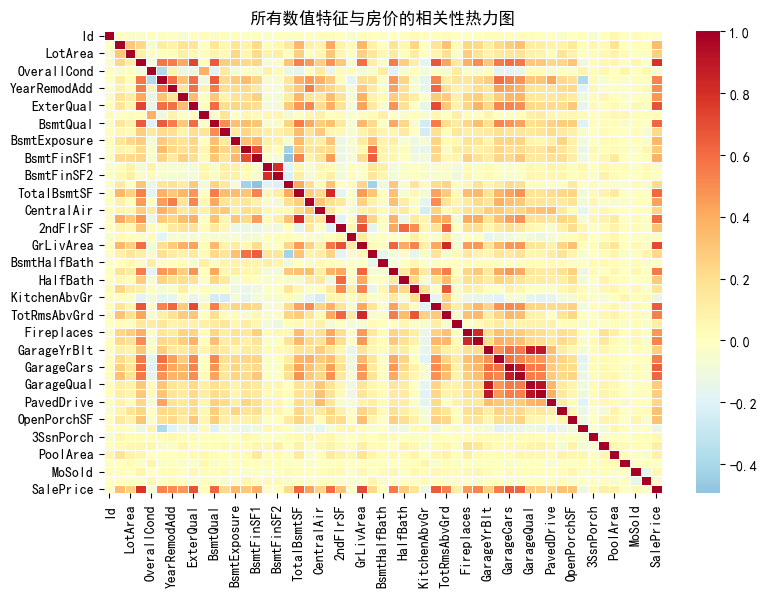

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 只看数值列，算相关矩阵
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = train[numeric_cols].corr()

# 画热力图
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, cmap='RdYlBu_r', center=0, 
            annot=False, fmt='.1f', linewidths=0.5)
plt.title('所有数值特征与房价的相关性热力图')
plt.show()

In [19]:
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split

# 删掉 Id，重新训练
if 'Id' in train.columns:
    train.drop('Id', axis=1, inplace=True)

X = train.drop('SalePrice', axis=1)
y = np.log1p(train['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model = LassoCV(cv=5, random_state=42, max_iter=5000)
# model.fit(X_train, y_train)

# print(f"最优 λ: {model.alpha_:.4f}")
# print(f"训练集 R²: {model.score(X_train, y_train):.3f}")
# print(f"测试集 R²: {model.score(X_test, y_test):.3f}")
# print(f"保留特征数: {(model.coef_ != 0).sum()} / {X.shape[1]}")

# # 查看新的特征排名
# coef_df = pd.DataFrame({'特征': X.columns, '系数': model.coef_})
# print(coef_df[coef_df['系数'] != 0].sort_values('系数', ascending=False))
from sklearn.linear_model import Lasso

# 用比最优 λ 更小的值
small_alphas = [1.0, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]

for a in small_alphas:
    m = Lasso(alpha=a, max_iter=5000)
    m.fit(X_train, y_train)
    n_feat = (m.coef_ != 0).sum()
    r2 = m.score(X_test, y_test)
    print(f"λ={a:.4f}  保留特征数={n_feat}  测试集 R²={r2:.3f}")

λ=1.0000  保留特征数=13  测试集 R²=0.805
λ=0.5000  保留特征数=14  测试集 R²=0.820
λ=0.1000  保留特征数=19  测试集 R²=0.825
λ=0.0500  保留特征数=22  测试集 R²=0.844
λ=0.0100  保留特征数=31  测试集 R²=0.877
λ=0.0050  保留特征数=41  测试集 R²=0.884
λ=0.0010  保留特征数=82  测试集 R²=0.895


In [20]:
# 用 λ=0.001 重新训练，看系数
model_final = Lasso(alpha=0.001, max_iter=5000)
model_final.fit(X_train, y_train)

coef_df = pd.DataFrame({
    '特征': X.columns,
    '系数': model_final.coef_
})
non_zero = coef_df[coef_df['系数'] != 0].sort_values('系数', ascending=False)
print(non_zero.to_string())

                        特征        系数
146    Exterior1st_BrkFace  0.084657
103   Neighborhood_StoneBr  0.081871
97    Neighborhood_NridgHt  0.081715
87    Neighborhood_Crawfor  0.076656
54           MSSubClass_20  0.061402
2              OverallQual  0.060170
37              GarageCars  0.051687
107        Condition1_Norm  0.049729
102   Neighborhood_Somerst  0.049520
24            BsmtFullBath  0.043504
19              CentralAir  0.039937
3              OverallCond  0.034643
84    Neighborhood_BrkSide  0.031196
76       LotConfig_CulDSac  0.030963
96    Neighborhood_NoRidge  0.030782
9                 BsmtQual  0.030470
27                HalfBath  0.029272
32              Functional  0.028736
209  SaleCondition_Partial  0.028640
177       Foundation_PConc  0.024127
26                FullBath  0.020819
39              GarageQual  0.019882
11            BsmtExposure  0.018927
191      GarageType_Attchd  0.016768
73         LandContour_HLS  0.016660
85    Neighborhood_ClearCr  0.016605
3

In [21]:
# ==================== 1. 读取测试集 ====================
test = pd.read_csv("test.csv")

# ==================== 2. 对测试集做完全相同的预处理 ====================

# 删掉和训练集相同的列
drop_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'Utilities', 'Id']
for col in drop_cols:
    if col in test.columns:
        test.drop(col, axis=1, inplace=True)

# One-Hot（用训练集里存在的那套列名，防止测试集多出训练集没有的取值）
nominal_cols_exist = [col for col in nominal_cols if col in test.columns]
test[nominal_cols_exist] = test[nominal_cols_exist].fillna('None')
if 'MSSubClass' in nominal_cols_exist:
    test['MSSubClass'] = test['MSSubClass'].astype(str)
test = pd.get_dummies(test, columns=nominal_cols_exist, drop_first=True)

# 有序特征映射
ordinal_cols_exist = [col for col in ordinal_cols if col in test.columns]
quality_map      = {'None': 0, 'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4}
exposure_map     = {'None': 0, 'No': 0, 'Mn': 1, 'Av': 2, 'Gd': 3}
fin_type_map     = {'None': 0, 'Unf': 0, 'LwQ': 1, 'Rec': 2, 'BLQ': 3, 'ALQ': 4, 'GLQ': 5}
garage_finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}

for col in ordinal_cols_exist:
    test[col] = test[col].fillna('None')
    if col == 'BsmtExposure':
        test[col] = test[col].map(exposure_map)
    elif col in ['BsmtFinType1', 'BsmtFinType2']:
        test[col] = test[col].map(fin_type_map)
    elif col == 'GarageFinish':
        test[col] = test[col].map(garage_finish_map)
    else:
        test[col] = test[col].map(quality_map)

# 二值映射
if 'CentralAir' in test.columns:
    test['CentralAir'] = test['CentralAir'].map({'N': 0, 'Y': 1})
if 'PavedDrive' in test.columns:
    test['PavedDrive'] = test['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})
if 'Functional' in test.columns:
    func_map = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}
    test['Functional'] = test['Functional'].fillna('Typ').map(func_map)

# 填数值缺失
test['LotFrontage'] = test['LotFrontage'].fillna(test['LotFrontage'].median())
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)
test['MasVnrArea']  = test['MasVnrArea'].fillna(0)

# 其他数值列如有缺失，填中位数
for col in test.select_dtypes(include=['int64', 'float64']).columns:
    if test[col].isnull().sum() > 0:
        test[col] = test[col].fillna(test[col].median())

# ==================== 3. 对齐训练集和测试集的列 ====================
missing_in_test = set(X.columns) - set(test.columns)
for col in missing_in_test:
    test[col] = 0
test = test[X.columns]  # 按训练集列顺序排列

# ==================== 4. 预测 & 还原对数变换 ====================
y_pred_log = model_final.predict(test)
y_pred = np.expm1(y_pred_log)  # 还原成原始美元

# ==================== 5. 生成提交文件 ====================
submission = pd.DataFrame({
    'Id': pd.read_csv("test.csv")['Id'],
    'SalePrice': y_pred
})
submission.to_csv("submission.csv", index=False)

print("submission.csv 已生成")
print(submission.head())

submission.csv 已生成
     Id      SalePrice
0  1461  113398.660105
1  1462  144251.075369
2  1463  171549.279365
3  1464  192595.736996
4  1465  200000.086265


In [22]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.1, 1, 10, 100], cv=5)
ridge.fit(X_train, y_train)
print(f"Ridge 测试集 R²: {ridge.score(X_test, y_test):.3f}")

# 预测并提交
y_pred_log_ridge = ridge.predict(test)
submission_ridge = pd.DataFrame({
    'Id': pd.read_csv("test.csv")['Id'],
    'SalePrice': np.expm1(y_pred_log_ridge)
})
submission_ridge.to_csv("submission_ridge.csv", index=False)

Ridge 测试集 R²: 0.900
